# HAR TFM

In [1]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

ruta_archivo_csv = "Datos Combinados/data/DatosCombinados_Total.csv"

df = pd.read_csv(ruta_archivo_csv)
print(df)


              Mz  Lilluminance            timestamp        Az  counter  \
0      -5.456250       19857.0  2023-06-11 09:54:24  0.775127        0   
1            NaN           NaN  2023-06-11 09:54:24  0.954223        1   
2      -9.018750           NaN  2023-06-11 09:54:25  0.820999        0   
3     -12.018750           NaN  2023-06-11 09:54:25  0.966667        1   
4     -12.825001           NaN  2023-06-11 09:54:25  0.834419        2   
...          ...           ...                  ...       ...      ...   
25450        NaN         119.0                  NaN       NaN        0   
25451        NaN        1068.0  2023-06-08 07:24:58       NaN        0   
25452        NaN         253.0  2023-06-08 07:25:03       NaN        1   
25453        NaN         240.0  2023-06-08 07:28:31       NaN        1   
25454        NaN       12163.0                  NaN       NaN        0   

             Gy        Ay        Gz         My          deviceId       Mx  \
0     -0.340853  0.531950  0.26045

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25455 entries, 0 to 25454
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Mz            22334 non-null  float64
 1   Lilluminance  6543 non-null   float64
 2   timestamp     25427 non-null  object 
 3   Az            24392 non-null  float64
 4   counter       25455 non-null  int64  
 5   Gy            22913 non-null  float64
 6   Ay            24392 non-null  float64
 7   Gz            22913 non-null  float64
 8   My            22334 non-null  float64
 9   deviceId      21896 non-null  object 
 10  Mx            22334 non-null  float64
 11  Bpressure     6552 non-null   float64
 12  Ax            24392 non-null  float64
 13  Gx            22913 non-null  float64
 14  activity      25455 non-null  int64  
dtypes: float64(11), int64(2), object(2)
memory usage: 2.9+ MB


## Reorganizar las columnas del csv. 

In [3]:
columnas_deseadas = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Mx", "My", "Mz", "Bpressure", "Lilluminance", "timestamp", "counter","deviceId", "activity"]  # Cambia los nombres de las columnas según tus necesidades
df = df.reindex(columns=columnas_deseadas)


## Ordenar los datos.

In [4]:
df.head()

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.158082,0.531950,0.775127,-0.111403,-0.340853,0.260450,0.56250,-45.337502,-5.456250,915.505005,19857.0,2023-06-11 09:54:24,0,d99f0327fa491f9f,1
1,-0.077317,0.495350,0.954223,-0.521053,-0.480737,-0.362767,NaN,NaN,NaN,915.512451,NaN,2023-06-11 09:54:24,1,d99f0327fa491f9f,1
2,-0.004362,0.585874,0.820999,-0.099644,-0.496084,-0.428662,-0.90000,-45.900002,-9.018750,915.538757,NaN,2023-06-11 09:54:25,0,d99f0327fa491f9f,1
3,0.050783,0.535123,0.966667,-0.148436,-0.291909,-0.541592,-0.20625,-45.712502,-12.018750,915.567505,NaN,2023-06-11 09:54:25,1,d99f0327fa491f9f,1
4,0.053467,0.418979,0.834419,-0.027564,-0.090405,-0.430266,0.78750,-45.393753,-12.825001,915.552490,NaN,2023-06-11 09:54:25,2,d99f0327fa491f9f,1


In [5]:
df = df.sort_values(by=["timestamp", "counter"])
df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
23157,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
23158,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
23159,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
23160,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
23161,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
23162,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
23163,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
23164,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
23165,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
23166,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


## Comprobación de datos nulos y no nulos para cada persona

In [6]:
# Agrupar por la columna "deviceId" y calcular el número de datos no nulos por columna
counts = df.groupby("deviceId").count()

# Calcular la suma de valores nulos por columna
null_counts = df.groupby("deviceId").apply(lambda x: x.isnull().sum())

# Mostrar el número de datos no nulos
counts.head(20)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,activity
deviceId,,,,,,,,,,,,,,
5a287c6d3ffda73f,1112,1112,1112,1045,1045,1045,1059,1059,1059,1052,1031,1181,1184,1184
629b502066d8a33a,220,220,220,157,157,157,157,157,157,0,194,235,235,235
73d32f5bb75976e4,1098,1098,1098,1058,1058,1058,1091,1091,1091,0,976,1139,1144,1144
8fe3a65e2ea6658d,9965,9965,9965,9363,9363,9363,9454,9454,9454,0,0,10340,10346,10346
b719b9175e5338b9,385,385,385,409,409,409,304,304,304,0,177,469,472,472
b973ac361183cbb0,616,616,616,555,555,555,591,591,591,0,461,693,693,693
bebf6a9bfd30c163,544,544,544,518,518,518,525,525,525,0,520,588,589,589
c32bdcc96f9e1fb1,768,768,768,746,746,746,576,576,576,0,460,839,842,842
ccbc9d76c2ebeaf5,1239,1239,1239,974,974,974,987,987,987,958,939,1358,1358,1358


In [7]:
# Mostrar el número de datos nulos
null_counts.head(20)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
deviceId,,,,,,,,,,,,,,,
5a287c6d3ffda73f,72,72,72,139,139,139,125,125,125,132,153,3,0,0,0
629b502066d8a33a,15,15,15,78,78,78,78,78,78,235,41,0,0,0,0
73d32f5bb75976e4,46,46,46,86,86,86,53,53,53,1144,168,5,0,0,0
8fe3a65e2ea6658d,381,381,381,983,983,983,892,892,892,10346,10346,6,0,0,0
b719b9175e5338b9,87,87,87,63,63,63,168,168,168,472,295,3,0,0,0
b973ac361183cbb0,77,77,77,138,138,138,102,102,102,693,232,0,0,0,0
bebf6a9bfd30c163,45,45,45,71,71,71,64,64,64,589,69,1,0,0,0
c32bdcc96f9e1fb1,74,74,74,96,96,96,266,266,266,842,382,3,0,0,0
ccbc9d76c2ebeaf5,119,119,119,384,384,384,371,371,371,400,419,0,0,0,0


## Selección de persona para analizar los datos

In [8]:
# Especificar el deviceId que deseas seleccionar
device_id = '8fe3a65e2ea6658d'

# Filtrar el DataFrame por el deviceId específico
device_data = df[df['deviceId'] == device_id]

## Comprobar si una de las columnas solo tiene valores nulos

In [9]:
# Verificar si alguna columna tiene solo valores no nulos
columnas_no_null = df.notnull().all()
print(columnas_no_null)

Ax              False
Ay              False
Az              False
Gx              False
Gy              False
Gz              False
Mx              False
My              False
Mz              False
Bpressure       False
Lilluminance    False
timestamp       False
counter          True
deviceId        False
activity         True
dtype: bool


## Comprobación de las columnas del sensor Acelerómetro

In [10]:
cantidad_nulos = df[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    1063
Ay    1063
Az    1063
dtype: int64


In [11]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Ax', 'Ay', 'Az']] = grouped[['Ax', 'Ay', 'Az']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
23157,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
23158,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
23159,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
23160,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
23161,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
23162,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
23163,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
23164,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
23165,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
23166,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


In [12]:
cantidad_nulos = df[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    0
Ay    0
Az    0
dtype: int64


## Comprobación de las columnas del sensor Giroscopio

In [13]:
cantidad_nulos = df[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    2542
Gy    2542
Gz    2542
dtype: int64


In [14]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Gx', 'Gy', 'Gz']] = grouped[['Gx', 'Gy', 'Gz']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
23157,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
23158,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
23159,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
23160,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
23161,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
23162,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
23163,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
23164,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
23165,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
23166,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


In [15]:
cantidad_nulos = df[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    0
Gy    0
Gz    0
dtype: int64


## Comprobación de las columnas del sensor Magnetrómetro

In [16]:
cantidad_nulos = df[['Mx', 'My', 'Mz']].isnull().sum()
print(cantidad_nulos)

Mx    3121
My    3121
Mz    3121
dtype: int64


In [17]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Mx', 'My', 'Mz']] = grouped[['Mx', 'My', 'Mz']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
23157,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
23158,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
23159,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
23160,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
23161,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
23162,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
23163,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
23164,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
23165,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
23166,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


In [18]:
cantidad_nulos = df[['Mx', 'My', 'Mz']].isnull().sum()
print(cantidad_nulos)

Mx    0
My    0
Mz    0
dtype: int64


## Comprobación de la columna timestamp

In [19]:
cantidad_nulos = df[['timestamp']].isnull().sum()
print(cantidad_nulos)

timestamp    28
dtype: int64


In [20]:
# Convertir la columna 'timestamp' a tipo datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Obtener el timestamp en minutos desde la época (1970-01-01 00:00:00)
df['timestamp'] = df['timestamp'].astype(int) // (10**9 * 60)

# Verificar los cambios
print(df['timestamp'])

23157     28098336
23158     28098336
23159     28098336
23160     28098336
23161     28098336
           ...    
25432   -153722868
25436   -153722868
25442   -153722868
25450   -153722868
25454   -153722868
Name: timestamp, Length: 25455, dtype: int64


/tmp/ipykernel_24530/1046296482.py:5: FutureWarning: casting datetime64[ns] values to int64 with .astype(...) is deprecated and will raise in a future version. Use .view(...) instead.
  df['timestamp'] = df['timestamp'].astype(int) // (10**9 * 60)


In [21]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['timestamp']] = grouped[['timestamp']].apply(lambda x: x.interpolate().fillna(method='bfill'))

In [22]:
cantidad_nulos = df[['timestamp']].isnull().sum()
print(cantidad_nulos)

timestamp    0
dtype: int64


## Comprobación de los sensores Barómetro y Luminancia

In [23]:
cantidad_nulos = df[['Bpressure', 'Lilluminance']].isnull().sum()
print(cantidad_nulos)

Bpressure       18903
Lilluminance    18912
dtype: int64


In [24]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Bpressure', 'Lilluminance']] = grouped[['Bpressure', 'Lilluminance']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
23157,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
23158,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
23159,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
23160,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
23161,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,943.964355,85.940033,28098336,2,8fe3a65e2ea6658d,5
23162,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,943.964355,85.940033,28098336,3,8fe3a65e2ea6658d,5
23163,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
23164,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
23165,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,943.964355,85.940033,28098337,0,8fe3a65e2ea6658d,5
23166,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,943.964355,85.940033,28098337,0,8fe3a65e2ea6658d,5


In [25]:
cantidad_nulos = df[['Bpressure', 'Lilluminance']].isnull().sum()
print(cantidad_nulos)

Bpressure       0
Lilluminance    0
dtype: int64


### Ajuste de columnas 

In [26]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

5    8901
1    6783
6    3602
4    2721
3    2177
2    1271
Name: activity, dtype: int64


In [27]:
# Eliminar las filas con los valores 3 y 6 en la columna 'activity'
#df = df.drop(df[(df['activity'] == 3) | (df['activity'] == 1)].index)
#df = df.drop(df[df['activity'] == 1].index)

#### Submuestreo y sobremuestreo de los valores

In [28]:
import pandas as pd
from sklearn.utils import resample

# Muestra la distribución actual de clases
print(df['activity'].value_counts())

# Separar en diferentes DataFrames para cada clase
df_classes = [df[df['activity'] == i] for i in df['activity'].unique()]

# Obtener la cantidad de datos de la clase mayoritaria
max_samples = max([len(df_class) for df_class in df_classes])

# Realizar el submuestreo y sobremuestreo para cada clase
df_balanced = []
for df_class in df_classes:
    df_class_upsampled = resample(df_class, replace=True, n_samples=max_samples, random_state=123)
    df_balanced.append(df_class_upsampled)

# Combinar todos los DataFrames balanceados para formar el DataFrame final
df = pd.concat(df_balanced)

5    8901
1    6783
6    3602
4    2721
3    2177
2    1271
Name: activity, dtype: int64


In [29]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

5    8901
1    8901
6    8901
3    8901
4    8901
2    8901
Name: activity, dtype: int64


# Correlación de datos

In [30]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity        1.000000
Lilluminance    0.224122
Bpressure       0.198422
Mz              0.099290
Mx              0.096327
Az              0.055857
counter         0.027015
Gx              0.025314
My              0.020964
Ax              0.012011
Gz              0.010415
Gy              0.009990
timestamp       0.003438
Ay              0.000816
Name: activity, dtype: float64


## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

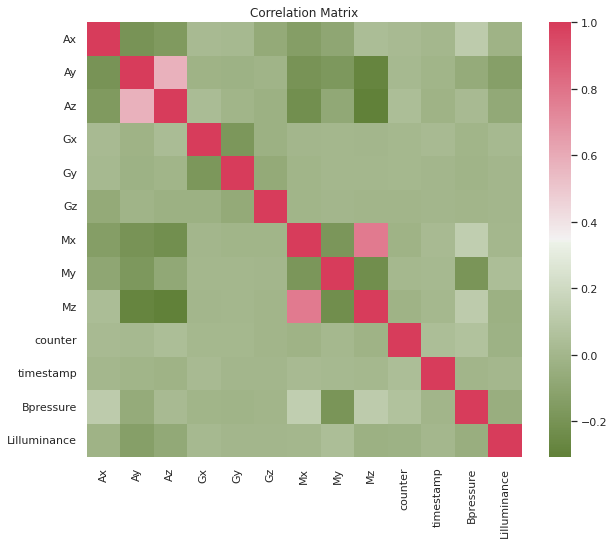

In [31]:
# Correlation matrix
CorrInfo = pd.DataFrame(df,columns=["Ax","Ay","Az","Gx","Gy","Gz","Mx","My","Mz","counter", "timestamp", 'Bpressure', 'Lilluminance'])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

In [32]:
#Square root of sum of squares of accelerometer, linear acceleration and gyroscope data
df["AxMy"] = np.sqrt(np.square(df['Ax']) + np.square(df['My']))
df["AxGy"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gy']))
df["AxC"] = np.sqrt(np.square(df['Ax']) + np.square(df['counter']))
df["Ayz"] = np.sqrt(np.square(df['Ay']) + np.square(df['Az']))
df["AyGz"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gz']))
df["AzGx"] = np.sqrt(np.square(df['Az']) + np.square(df['Gx']))
df["Gzy"] = np.sqrt(np.square(df['Gz']) + np.square(df['Gy']) )
df["MxGy"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gy']) )
df["MxGx"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gx']) )
df["MyGy"] = np.sqrt(np.square(df['My']) + np.square(df['Gy']) )
df["MyGx"] = np.sqrt(np.square(df['My']) + np.square(df['Gx']) )
df["Myz"] = np.sqrt(np.square(df['My']) + np.square(df['Mz']))
df["Mxz"] = np.sqrt(np.square(df['Mx']) + np.square(df['Mz']))

In [33]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity        1.000000
Lilluminance    0.224122
Bpressure       0.198422
Myz             0.124473
Mxz             0.114977
MxGx            0.103269
MxGy            0.103194
Mz              0.099290
Mx              0.096327
MyGy            0.078809
MyGx            0.078725
AxMy            0.078669
Ayz             0.069541
Az              0.055857
Gzy             0.037784
counter         0.027015
Gx              0.025314
AxC             0.024155
AzGx            0.023939
My              0.020964
AxGy            0.016480
Ax              0.012011
Gz              0.010415
Gy              0.009990
AyGz            0.008324
timestamp       0.003438
Ay              0.000816
Name: activity, dtype: float64


# Modelo de red neuronal

In [34]:
#Para ver la mayor corelación
features = ["Ayz", 'Ax', "Az", "AxMy", "AyGz", "AxGy", "AzGx", "MyGy", "MyGx", "Myz", "Mx", "Mxz", "MxGx", "MxGy", 'Mz', 'Bpressure', 'Lilluminance']
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 53406
Número de columnas: 17


In [35]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = df[features]
y = df['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
#model.add(LSTM(128, input_shape=(1, X_train.shape[2])))
#model.add(Dense(5, activation='softmax'))
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
model.add(LSTM(128))
model.add(Dense(6, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


2023-07-24 11:58:46.166347: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-24 11:58:47.974424: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-24 11:58:47.986406: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-24 11:58:56.975330: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
2023

Epoch 1/20


2023-07-24 11:59:08.682444: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-07-24 11:59:08.683738: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-07-24 11:59:08.684849: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

661/668 [============================>.] - ETA: 0s - loss: 1.0196 - accuracy: 0.6175

2023-07-24 11:59:15.446615: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-07-24 11:59:15.447752: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-07-24 11:59:15.448825: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

668/668 [==============================] - 8s 8ms/step - loss: 1.0185 - accuracy: 0.6181 - val_loss: 0.8855 - val_accuracy: 0.6679
Epoch 2/20
668/668 [==============================] - 5s 7ms/step - loss: 0.8455 - accuracy: 0.6864 - val_loss: 0.8114 - val_accuracy: 0.6982
Epoch 3/20
668/668 [==============================] - 4s 7ms/step - loss: 0.8071 - accuracy: 0.7033 - val_loss: 0.7292 - val_accuracy: 0.7344
Epoch 4/20
668/668 [==============================] - 5s 7ms/step - loss: 0.7458 - accuracy: 0.7260 - val_loss: 0.7005 - val_accuracy: 0.7415
Epoch 5/20
668/668 [==============================] - 5s 7ms/step - loss: 0.7206 - accuracy: 0.7329 - val_loss: 0.7305 - val_accuracy: 0.7255
Epoch 6/20
668/668 [==============================] - 5s 7ms/step - loss: 0.6942 - accuracy: 0.7426 - val_loss: 0.6860 - val_accuracy: 0.7399
Epoch 7/20
668/668 [==============================] - 5s 7ms/step - loss: 0.6691 - accuracy: 0.7469 - val_loss: 0.6618 - val_accuracy: 0.7528
Epoch 8/20
668/66

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2023-07-24 12:00:46.865127: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-07-24 12:00:46.866080: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-07-24 12:00:46.867158: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

334/334 [==============================] - 1s 1ms/step
Accuracy: 0.8126755289271672
Precision: 0.8164992759591629
Recall: 0.8126755289271672
F1 Score: 0.8107851552738599


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

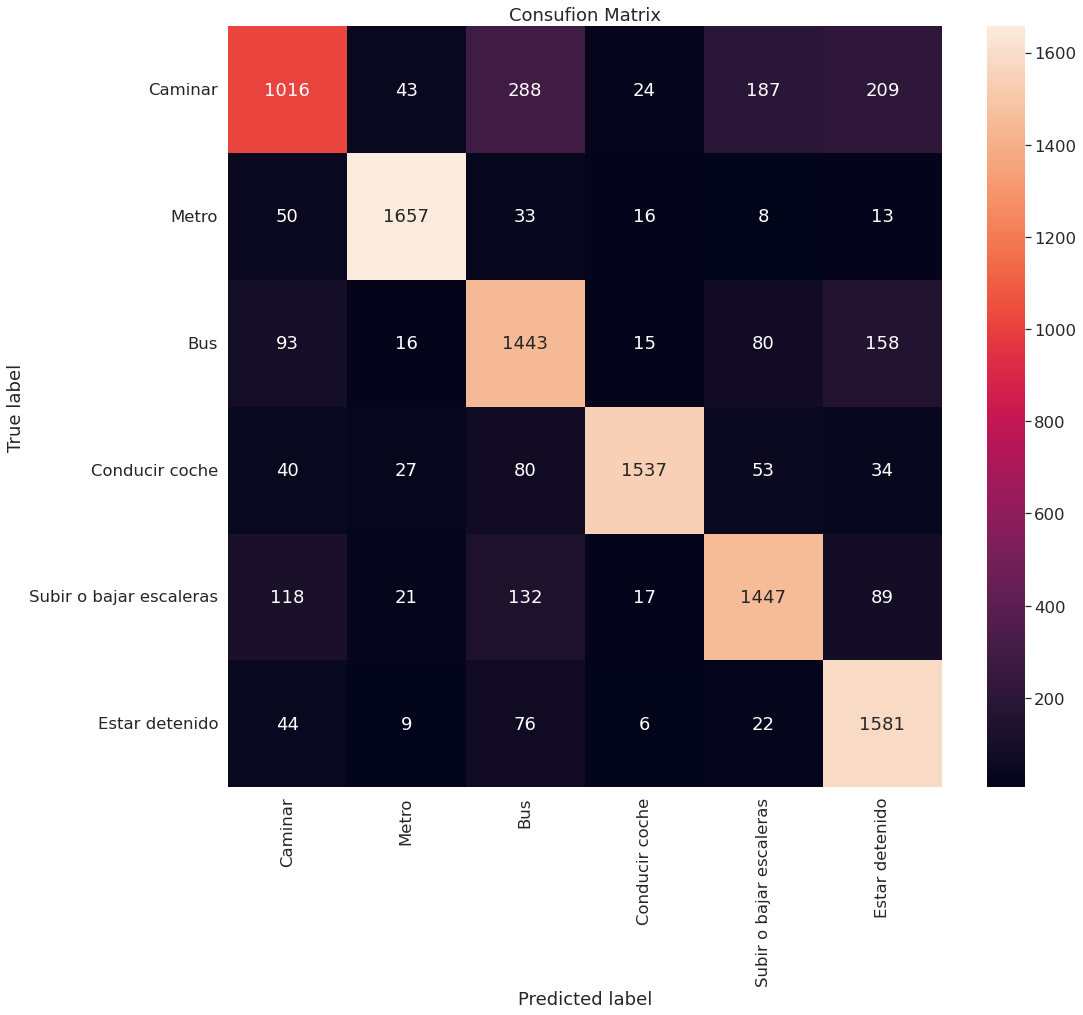

In [37]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

#Labels=['Caminar', 'Metro', 'Conducir coche', 'Subir o bajar escaleras']
#Labels=['Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
#Labels=['Metro', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [38]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

# Imprimir el resultado
for valor, conteo in zip(valores, conteos):
    print(f"Valor: {valor}, Cantidad: {conteo}")

Valor: 0, Cantidad: 1767
Valor: 1, Cantidad: 1777
Valor: 2, Cantidad: 1805
Valor: 3, Cantidad: 1771
Valor: 4, Cantidad: 1824
Valor: 5, Cantidad: 1738
